In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
wide_pass = pd.read_csv("/content/drive/MyDrive/CS506 Project/MBTA_2024_System-Wide_Passenger_Survey.csv")

In [ ]:
mbta = pd.read_csv("/content/drive/MyDrive/CS506 Project/mbta_final.csv", nrows=900)

In [ ]:
wide_pass.head(5)

,aggregation_level,service_mode,reporting_group,measure_group,measure,category,weighted_percent,ObjectId
0,Reporting Group,Bus,10,Alternative Modes,Alternative Mode,Drive or Ride in a Carpool,0.316855,1
1,Reporting Group,Bus,10,Alternative Modes,Alternative Mode,"Bike, Scooter, or Other Micromobility",0.000000,2
2,Reporting Group,Bus,10,Alternative Modes,Alternative Mode,Private Shuttle or Other Transit,0.000000,3
3,Reporting Group,Bus,10,Alternative Modes,Alternative Mode,Other,0.000000,4
4,Reporting Group,Bus,10,Alternative Modes,Used Alternative Mode,No,0.837547,5


In [ ]:
wide_pass.isnull().sum()

,0
aggregation_level,0
service_mode,0
reporting_group,0
measure_group,0
measure,0
category,9
weighted_percent,0
ObjectId,0


In [ ]:
wide_pass.category.unique()

array(['Drive or Ride in a Carpool',
       'Bike, Scooter, or Other Micromobility',
       'Private Shuttle or Other Transit', 'Other', 'No', 'Yes',
       'Monthly Pass', 'Pay-as-you-go', '7-day Pass', 'Student Pass (M7)',
       '1-day Pass', 'Full Fare', 'Full Fare - Subsidized by Employer',
       'Student (S-Card or M7)', 'Senior CharlieCard', 'Youth Pass',
       'Transportation Access Pass (TAP)', 'Other Reduced or Free Fare',
       'Less than 40% of Area Median Income',
       '30% to 60% of Area Median Income',
       '60% to 80% of Area Median Income',
       '80% to 100% of Area Median Income',
       '100% to 140%  of Area Median Income',
       '130% to 200% of Area Median Income', 'Prefer not to say',
       'Always', 'Often', 'Sometimes', 'Never', 'Under 18', '18 to 25',
       '26 to 34', '35 to 44', '45 to 64', '65 or older', 'Female',
       'Male', 'Non-Binary', 'American Indian or Alaska Native', 'Asian',
       'Black or African American', 'Middle Eastern or Nort

In [ ]:
wide_pass['category'].value_counts()

,count
category,
Prefer not to say,707
Yes,632
No,632
Other,517
0,316
...,...
200% or more of Area Median Income,141
Never,131
The RIDE,130


In [ ]:
wide_pass[wide_pass['category'].isnull()]

,aggregation_level,service_mode,reporting_group,measure_group,measure,category,weighted_percent,ObjectId
12855,Rapid Transit or Bus Rapid Transit Line,Rapid Transit or Bus Rapid Transit - Green Line,All Green Line,Vehicles,Cars per Capita,NaN,0.013839,12856
12864,Rapid Transit or Bus Rapid Transit Line,Rapid Transit or Bus Rapid Transit - Blue Line,All Blue Line,Vehicles,Cars per Capita,NaN,0.010105,12865
13206,Rapid Transit or Bus Rapid Transit Line,Rapid Transit or Bus Rapid Transit - Silver Li...,All Silver Line BRT,Vehicles,Cars per Capita,NaN,0.016516,13207
13380,Rapid Transit or Bus Rapid Transit Line,Rapid Transit or Bus Rapid Transit - Red Line,All Red Line,Vehicles,Cars per Capita,NaN,0.021756,13381
13453,Rapid Transit or Bus Rapid Transit Line,Rapid Transit or Bus Rapid Transit - Orange Line,All Orange Line,Vehicles,Cars per Capita,NaN,0.018571,13454
13550,Service Mode,Commuter Rail,All Commuter Rail,Vehicles,Cars per Capita,NaN,0.058230,13551
13587,Service Mode,Bus,All Bus,Vehicles,Cars per Capita,NaN,0.017421,13588
13673,Service Mode,Rapid Transit or Bus Rapid Transit,All Rapid Transit or Bus Rapid Transit,Vehicles,Cars per Capita,NaN,0.016740,13674
13819,Systemwide,All Modes,Systemwide,Vehicles,Cars per Capita,NaN,0.021866,13820


In [ ]:
wide_pass['category'] = wide_pass['category'].fillna('Other')

In [ ]:
wide_pass.dtypes

,0
aggregation_level,object
service_mode,object
reporting_group,object
measure_group,object
measure,object
category,object
weighted_percent,float64
ObjectId,int64


In [ ]:
wide_pass.duplicated().sum()

np.int64(0)

In [ ]:
serv = wide_pass.service_mode.unique()
rg = wide_pass.reporting_group.unique()

print(f"service group: {serv}")
print(f"reporting_group: {rg}")

# wide_pass['reporting_group'] = wide_pass['reporting_group'].astype('string') NOT DOING YOU THIS BECAUSE HAS NUMBERS

wide_pass['service_mode'] = wide_pass['service_mode'].astype('string')

service group: ['Bus' 'Commuter Rail' 'Ferry'
 'Rapid Transit or Bus Rapid Transit - Blue Line'
 'Rapid Transit or Bus Rapid Transit - Green Line'
 'Rapid Transit or Bus Rapid Transit - Mattapan Trolley'
 'Rapid Transit or Bus Rapid Transit - Orange Line'
 'Rapid Transit or Bus Rapid Transit - Red Line'
 'Rapid Transit or Bus Rapid Transit - Silver Line BRT'
 'Rapid Transit or Bus Rapid Transit' 'All Modes']
reporting_group: ['10' '1' '104' '111' '11' '21' '114, 116, & 117' '15' '16' '22' '28 & 29'
 '23' '32' '34 & 34E' '39' '43 & SL5' '4 & 7' '47' '57' '66' '61 & 70'
 '67 & 77' '71' '73' '9' '86' 'Brighton/Allston/Watertown - Boston'
 '8, 55 & CT3' 'Brighton/Allston/Watertown - Other Suburb'
 'Chelsea/East Boston/Lynn/Revere - Core' 'Cambridge/Arlington - Alewife'
 'Cambridge/Arlington - Harvard'
 'Chelsea/East Boston/Lynn/Revere - North Shore' 'Malden/Everett - South'
 'Malden/Everett - North' 'Quincy - East'
 'Jamaica Plain/Roslindale/Hyde Park'
 'Roxbury/Dorchester/Mattapan/South E

In [ ]:
AL = wide_pass.aggregation_level.unique()
print(AL)
wide_pass['aggregation_level'] = wide_pass['aggregation_level'].astype('string')

['Reporting Group' 'Rapid Transit or Bus Rapid Transit Line'
 'Service Mode' 'Systemwide']


In [ ]:
mg = wide_pass.measure.unique()
measure = wide_pass.measure_group.unique()

wide_pass['measure_group'] = wide_pass['measure_group'].astype('string')
wide_pass['measure'] = wide_pass['measure'].astype('string')

print(mg)
print(measure)

['Alternative Mode' 'Used Alternative Mode' 'Fare Product' 'Reduced Fares'
 'Household Income' 'Title VI Low-Income' 'Ability to Understand English'
 'Age' 'Gender' 'Hispanic or Latine' 'Race' 'Access to First MBTA Service'
 'Title VI Minority' 'Frequency' 'Trip Purpose' 'Cars per Capita'
 'Usable Cars']
['Alternative Modes' 'Fares' 'Income' 'Other Demographics'
 'Race and Ethnicity' 'Access Mode' 'Trip Purpose and Frequency'
 'Vehicles']


In [ ]:
wide_pass.category.unique()

array(['Drive or Ride in a Carpool',
       'Bike, Scooter, or Other Micromobility',
       'Private Shuttle or Other Transit', 'Other', 'No', 'Yes',
       'Monthly Pass', 'Pay-as-you-go', '7-day Pass', 'Student Pass (M7)',
       '1-day Pass', 'Full Fare', 'Full Fare - Subsidized by Employer',
       'Student (S-Card or M7)', 'Senior CharlieCard', 'Youth Pass',
       'Transportation Access Pass (TAP)', 'Other Reduced or Free Fare',
       'Less than 40% of Area Median Income',
       '30% to 60% of Area Median Income',
       '60% to 80% of Area Median Income',
       '80% to 100% of Area Median Income',
       '100% to 140%  of Area Median Income',
       '130% to 200% of Area Median Income', 'Prefer not to say',
       'Always', 'Often', 'Sometimes', 'Never', 'Under 18', '18 to 25',
       '26 to 34', '35 to 44', '45 to 64', '65 or older', 'Female',
       'Male', 'Non-Binary', 'American Indian or Alaska Native', 'Asian',
       'Black or African American', 'Middle Eastern or Nort

In [ ]:
wide_pass.dtypes

,0
aggregation_level,string[python]
service_mode,string[python]
reporting_group,object
measure_group,string[python]
measure,string[python]
category,object
weighted_percent,float64
ObjectId,int64


In [ ]:
print("======== Shape =======")
print(wide_pass.shape)
print(wide_pass.info)

======== Shape =======
(13866, 8)
<bound method DataFrame.info of       aggregation_level                        service_mode  \
0       Reporting Group                                 Bus   
1       Reporting Group                                 Bus   
2       Reporting Group                                 Bus   
3       Reporting Group                                 Bus   
4       Reporting Group                                 Bus   
...                 ...                                 ...   
13861      Service Mode  Rapid Transit or Bus Rapid Transit   
13862        Systemwide                           All Modes   
13863      Service Mode  Rapid Transit or Bus Rapid Transit   
13864      Service Mode  Rapid Transit or Bus Rapid Transit   
13865      Service Mode  Rapid Transit or Bus Rapid Transit   

                              reporting_group      measure_group  \
0                                          10  Alternative Modes   
1                                        

In [ ]:
print(wide_pass.columns.tolist())

['aggregation_level', 'service_mode', 'reporting_group', 'measure_group', 'measure', 'category', 'weighted_percent', 'ObjectId']


In [ ]:
# Strip leading/trailing whitespace from ALL string/object columns
str_cols = wide_pass.select_dtypes(include=["object", "string"]).columns
for col in str_cols:
    wide_pass[col] = wide_pass[col].str.strip()

print("\n=== After stripping whitespace ===")
print("Done. Checking for empty strings that might be hidden nulls...")


=== After stripping whitespace ===
Done. Checking for empty strings that might be hidden nulls...


In [ ]:
wide_pass.replace("", np.nan, inplace=True)

In [ ]:
print("\n=== NULL COUNTS ===")
print(wide_pass.isnull().sum())
print(f"\nTotal nulls: {wide_pass.isnull().sum().sum()}")
print(f"Rows with any null: {wide_pass.isnull().any(axis=1).sum()}")


=== NULL COUNTS ===
aggregation_level    0
service_mode         0
reporting_group      0
measure_group        0
measure              0
category             0
weighted_percent     0
ObjectId             0
dtype: int64

Total nulls: 0
Rows with any null: 0


In [ ]:
dupes = wide_pass.duplicated().sum()
print(f"\n=== DUPLICATES: {dupes} ===")
if dupes > 0:
    print("Dropping duplicates...")
    wide_pass.drop_duplicates(inplace=True)
    print(f"New shape: {wide_pass.shape}")


=== DUPLICATES: 0 ===


In [ ]:
keep_modes = [
    "Bus",
    "Rapid Transit or Bus Rapid Transit - Silver Line BRT",
    "All Modes"  # for baseline comparison
]

wide_pass_bus = wide_pass[wide_pass["service_mode"].isin(keep_modes)].copy()

In [ ]:
print(wide_pass_bus["reporting_group"].unique())

['10' '1' '104' '111' '11' '21' '114, 116, & 117' '15' '16' '22' '28 & 29'
 '23' '32' '34 & 34E' '39' '43 & SL5' '4 & 7' '47' '57' '66' '61 & 70'
 '67 & 77' '71' '73' '9' '86' 'Brighton/Allston/Watertown - Boston'
 '8, 55 & CT3' 'Brighton/Allston/Watertown - Other Suburb'
 'Chelsea/East Boston/Lynn/Revere - Core' 'Cambridge/Arlington - Alewife'
 'Cambridge/Arlington - Harvard'
 'Chelsea/East Boston/Lynn/Revere - North Shore' 'Malden/Everett - South'
 'Malden/Everett - North' 'Quincy - East'
 'Jamaica Plain/Roslindale/Hyde Park'
 'Roxbury/Dorchester/Mattapan/South End - East' 'Quincy - West'
 'Roxbury/Dorchester/Mattapan/South End & Jamaica Plain/Roslindale/Hyde Park'
 'Roxbury/Dorchester/Mattapan/South End - West' 'SL4'
 'Somerville/Medford/Charlestown - East'
 'Somerville/Medford/Charlestown - West' 'SL1' 'SL2' 'SL3'
 'All Silver Line BRT' 'All Bus' 'Systemwide']


In [ ]:
# Sanity check — what reporting groups remain?
print("\n=== REPORTING GROUPS AFTER FILTER ===")
for g in sorted(wide_pass_bus["reporting_group"].unique()):
    print(f"  {g}")


=== REPORTING GROUPS AFTER FILTER ===
  1
  10
  104
  11
  111
  114, 116, & 117
  15
  16
  21
  22
  23
  28 & 29
  32
  34 & 34E
  39
  4 & 7
  43 & SL5
  47
  57
  61 & 70
  66
  67 & 77
  71
  73
  8, 55 & CT3
  86
  9
  All Bus
  All Silver Line BRT
  Brighton/Allston/Watertown - Boston
  Brighton/Allston/Watertown - Other Suburb
  Cambridge/Arlington - Alewife
  Cambridge/Arlington - Harvard
  Chelsea/East Boston/Lynn/Revere - Core
  Chelsea/East Boston/Lynn/Revere - North Shore
  Jamaica Plain/Roslindale/Hyde Park
  Malden/Everett - North
  Malden/Everett - South
  Quincy - East
  Quincy - West
  Roxbury/Dorchester/Mattapan/South End & Jamaica Plain/Roslindale/Hyde Park
  Roxbury/Dorchester/Mattapan/South End - East
  Roxbury/Dorchester/Mattapan/South End - West
  SL1
  SL2
  SL3
  SL4
  Somerville/Medford/Charlestown - East
  Somerville/Medford/Charlestown - West
  Systemwide


In [ ]:
AGGREGATE_GROUPS = ["All Bus", "All Silver Line BRT", "Systemwide"]
SILVER_LINE_ROUTES = ["SL1", "SL2", "SL3", "SL4", "43 & SL5"]

In [ ]:
def classify_reporting_group(group_name):
    """Classify each reporting_group into a category."""
    if group_name in AGGREGATE_GROUPS:
        return "system_aggregate"
    elif group_name in SILVER_LINE_ROUTES:
        return "silver_line_route"
    elif "/" in str(group_name) or " - " in str(group_name):
        return "neighborhood_aggregate"
    else:
        return "bus_route"

In [ ]:
wide_pass_bus["group_type"] = wide_pass_bus["reporting_group"].apply(
    classify_reporting_group
)

print("\n=== GROUP TYPE COUNTS ===")
print(wide_pass_bus["group_type"].value_counts())
print("\nBreakdown:")
for gtype in wide_pass_bus["group_type"].unique():
    subset = wide_pass_bus[wide_pass_bus["group_type"] == gtype]
    groups = sorted(subset["reporting_group"].unique())
    print(f"\n  {gtype} ({len(groups)} groups):")
    for g in groups:
        print(f"    {g}")


=== GROUP TYPE COUNTS ===
group_type
bus_route                 2245
neighborhood_aggregate    1402
silver_line_route          440
system_aggregate           275
Name: count, dtype: int64

Breakdown:

  bus_route (26 groups):
    1
    10
    104
    11
    111
    114, 116, & 117
    15
    16
    21
    22
    23
    28 & 29
    32
    34 & 34E
    39
    4 & 7
    47
    57
    61 & 70
    66
    67 & 77
    71
    73
    8, 55 & CT3
    86
    9

  silver_line_route (5 groups):
    43 & SL5
    SL1
    SL2
    SL3
    SL4

  neighborhood_aggregate (16 groups):
    Brighton/Allston/Watertown - Boston
    Brighton/Allston/Watertown - Other Suburb
    Cambridge/Arlington - Alewife
    Cambridge/Arlington - Harvard
    Chelsea/East Boston/Lynn/Revere - Core
    Chelsea/East Boston/Lynn/Revere - North Shore
    Jamaica Plain/Roslindale/Hyde Park
    Malden/Everett - North
    Malden/Everett - South
    Quincy - East
    Quincy - West
    Roxbury/Dorchester/Mattapan/South End & Jamaica P

In [ ]:
# ============================================================
# 7. VALIDATE weighted_percent
# ============================================================
print("\n=== WEIGHTED_PERCENT VALIDATION ===")
print(f"Min:          {wide_pass_bus['weighted_percent'].min()}")
print(f"Max:          {wide_pass_bus['weighted_percent'].max()}")
print(f"Any negative? {(wide_pass_bus['weighted_percent'] < 0).sum()}")
print(f"Any > 1.0?    {(wide_pass_bus['weighted_percent'] > 1.0).sum()}")
print(f"Any NaN?      {wide_pass_bus['weighted_percent'].isna().sum()}")


=== WEIGHTED_PERCENT VALIDATION ===
Min:          0.0
Max:          0.976279400455607
Any negative? 0
Any > 1.0?    0
Any NaN?      0


In [ ]:
# Check if percentages sum to ~1.0 within each group
pct_sums = (
    wide_pass_bus.groupby(["reporting_group", "measure_group", "measure"])[
        "weighted_percent"
    ]
    .sum()
    .reset_index()
)
pct_sums.columns = ["reporting_group", "measure_group", "measure", "pct_sum"]

bad_sums = pct_sums[abs(pct_sums["pct_sum"] - 1.0) > 0.05]
print(f"\nGroups where pct doesn't sum to ~1.0: {len(bad_sums)}")
if len(bad_sums) > 0:
    print(bad_sums.head(10))


Groups where pct doesn't sum to ~1.0: 95
    reporting_group       measure_group           measure   pct_sum
1                 1   Alternative Modes  Alternative Mode  1.377094
11                1  Race and Ethnicity              Race  1.074538
18               10   Alternative Modes  Alternative Mode  1.457117
35              104   Alternative Modes  Alternative Mode  1.409077
45              104  Race and Ethnicity              Race  1.108413
52               11   Alternative Modes  Alternative Mode  1.381558
62               11  Race and Ethnicity              Race  1.105853
69              111   Alternative Modes  Alternative Mode  1.066382
79              111  Race and Ethnicity              Race  1.104630
86  114, 116, & 117   Alternative Modes  Alternative Mode  1.287409


In [ ]:
# See which measures sum above 1.0 (multi-select)
# vs which sum to ~1.0 (mutually exclusive)
pct_summary = pct_sums.groupby("measure")["pct_sum"].agg(["mean", "max"]).round(3)
print(pct_summary.sort_values("max", ascending=False))

                                mean    max
measure                                    
Alternative Mode               1.329  1.788
Race                           1.080  1.151
Ability to Understand English  1.000  1.000
Age                            1.000  1.000
Access to First MBTA Service   1.000  1.000
Fare Product                   1.000  1.000
Frequency                      1.000  1.000
Gender                         1.000  1.000
Cars per Capita                0.982  1.000
Hispanic or Latine             1.000  1.000
Household Income               1.000  1.000
Reduced Fares                  1.000  1.000
Title VI Low-Income            1.000  1.000
Title VI Minority              1.000  1.000
Trip Purpose                   1.000  1.000
Usable Cars                    1.000  1.000
Used Alternative Mode          1.000  1.000


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [ ]:
# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 6)

In [ ]:
def get_measure_data(df, measure_name, group_types=["bus_route", "silver_line_route"]):
    """Extract data for a single measure, filtered to route-level."""
    return df[
        (df["measure"] == measure_name) & (df["group_type"].isin(group_types))
    ].copy()

In [ ]:
print(wide_pass_bus.columns.tolist())

['aggregation_level', 'service_mode', 'reporting_group', 'measure_group', 'measure', 'category', 'weighted_percent', 'ObjectId', 'group_type']


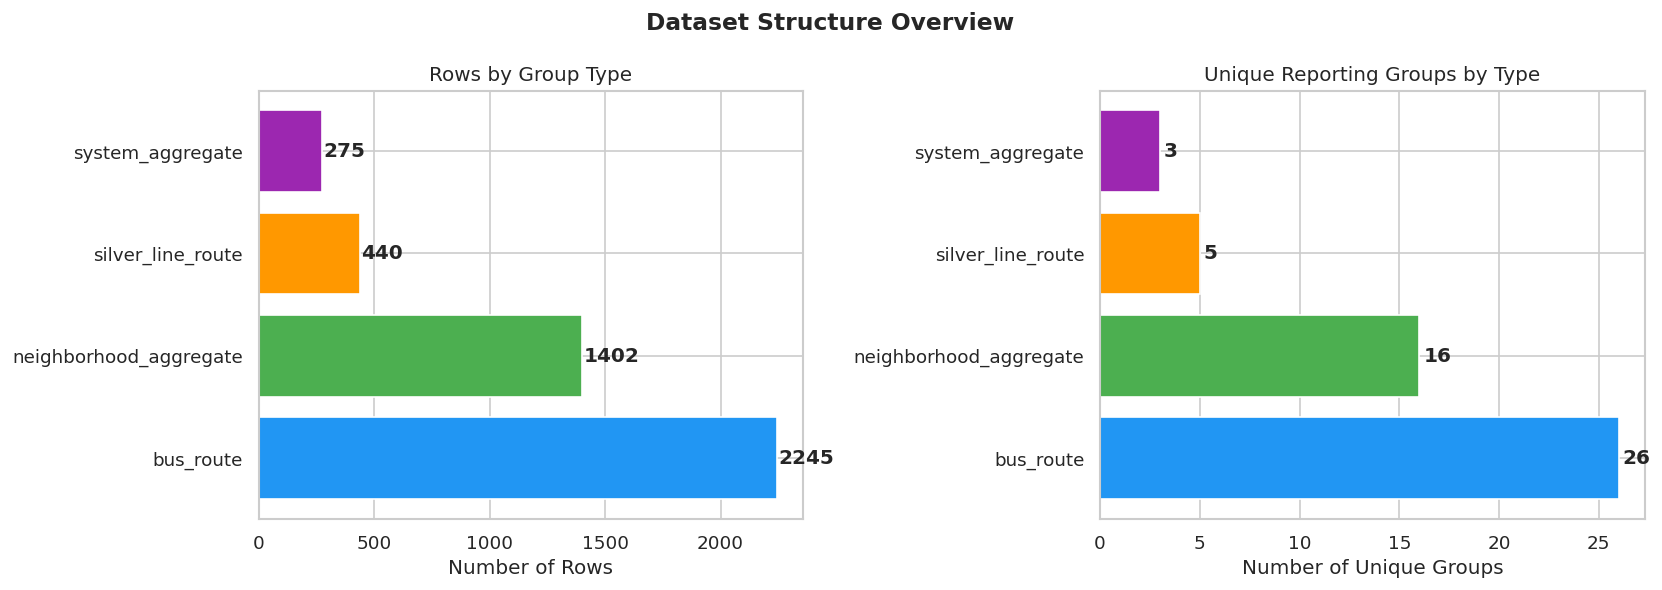

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count of rows per group type
type_counts = wide_pass_bus["group_type"].value_counts()
colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]
axes[0].barh(type_counts.index, type_counts.values, color=colors[:len(type_counts)])
axes[0].set_xlabel("Number of Rows")
axes[0].set_title("Rows by Group Type")
for i, v in enumerate(type_counts.values):
    axes[0].text(v + 5, i, str(v), va="center", fontweight="bold")

# Count of unique reporting groups per type
group_counts = wide_pass_bus.groupby("group_type")["reporting_group"].nunique()
axes[1].barh(group_counts.index, group_counts.values, color=colors[:len(group_counts)])
axes[1].set_xlabel("Number of Unique Groups")
axes[1].set_title("Unique Reporting Groups by Type")
for i, v in enumerate(group_counts.values):
    axes[1].text(v + 0.2, i, str(v), va="center", fontweight="bold")

plt.suptitle("Dataset Structure Overview", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("viz1_group_type_distribution.png", bbox_inches="tight")
plt.show()

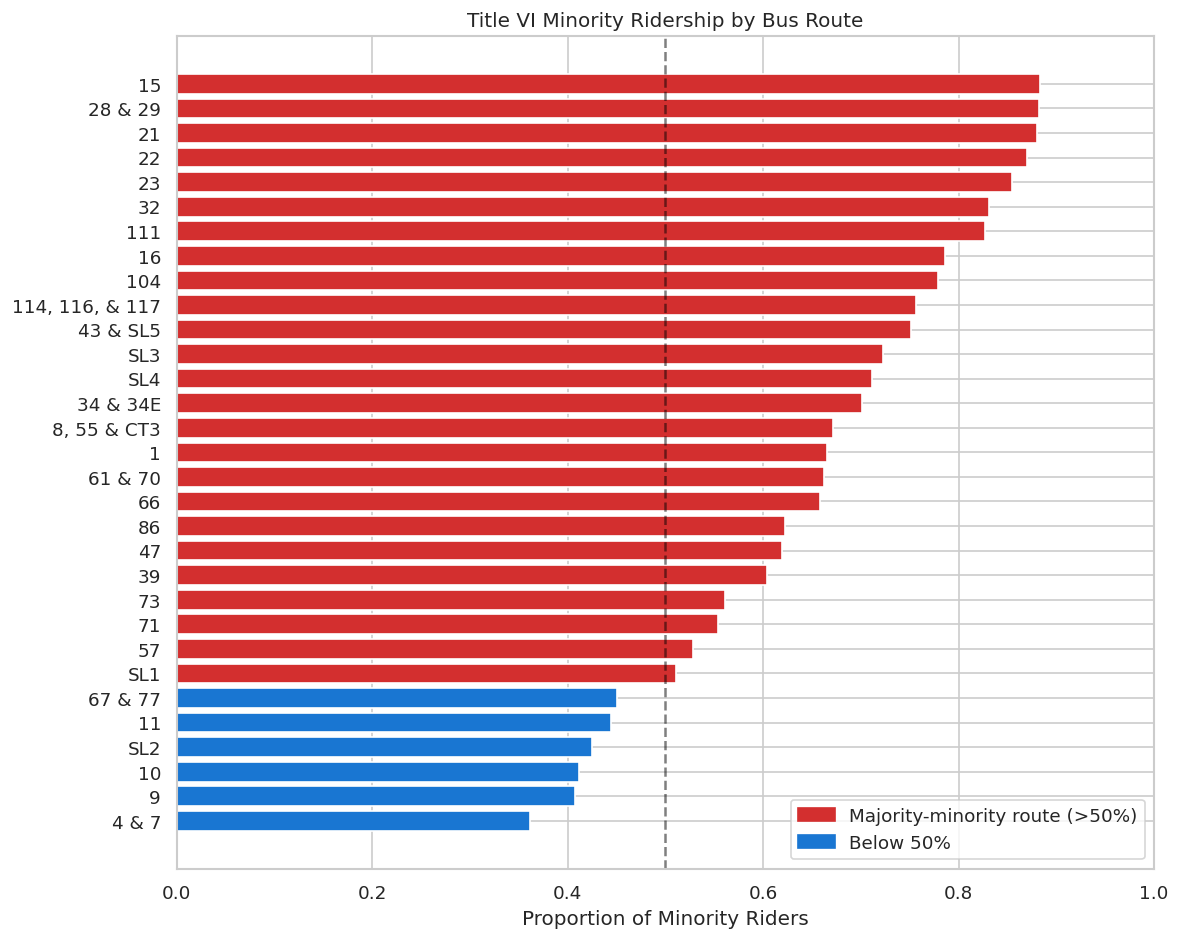

In [ ]:
# VIZ 2: TITLE VI MINORITY RIDERSHIP BY ROUTE
# What it tells you: Which routes serve the highest proportion
# of minority riders — directly relevant to your equity analysis.
# ============================================================
minority_data = get_measure_data(wide_pass_bus, "Title VI Minority")
minority_yes = minority_data[minority_data["category"] == "Yes"].copy()

if not minority_yes.empty:
    minority_yes = minority_yes.sort_values("weighted_percent", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    bar_colors = ["#D32F2F" if p > 0.5 else "#1976D2" for p in minority_yes["weighted_percent"]]
    ax.barh(minority_yes["reporting_group"], minority_yes["weighted_percent"], color=bar_colors)
    ax.axvline(x=0.5, color="black", linestyle="--", alpha=0.5, label="50% threshold")
    ax.set_xlabel("Proportion of Minority Riders")
    ax.set_title("Title VI Minority Ridership by Bus Route")
    ax.set_xlim(0, 1)

    red_patch = mpatches.Patch(color="#D32F2F", label="Majority-minority route (>50%)")
    blue_patch = mpatches.Patch(color="#1976D2", label="Below 50%")
    ax.legend(handles=[red_patch, blue_patch], loc="lower right")

    plt.tight_layout()
    plt.savefig("viz2_minority_ridership.png", bbox_inches="tight")
    plt.show()

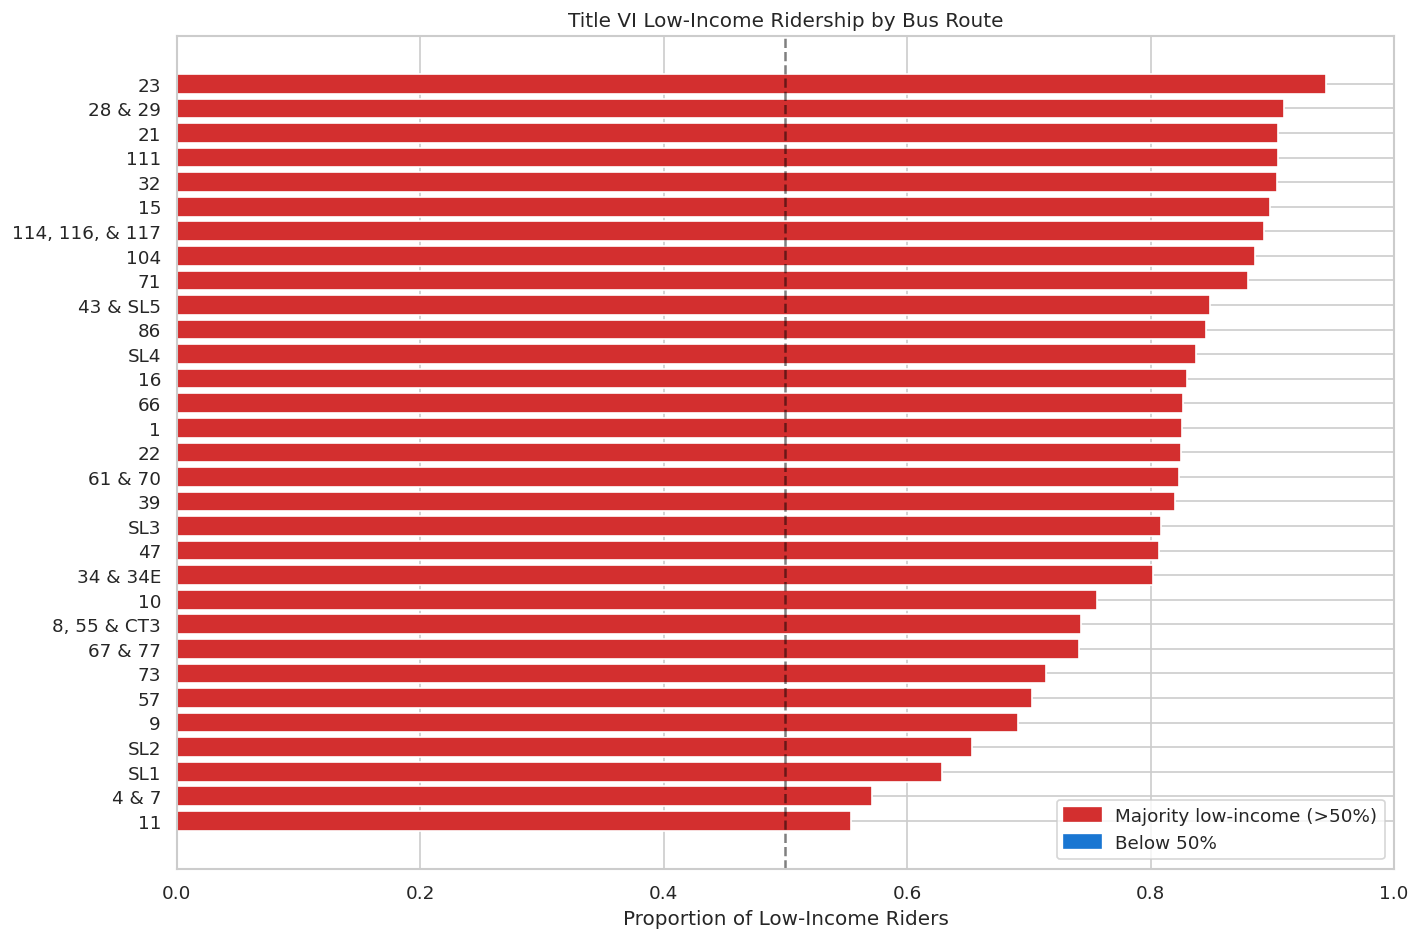

In [ ]:
lowinc_data = get_measure_data(wide_pass_bus, "Title VI Low-Income")
lowinc_yes = lowinc_data[lowinc_data["category"] == "Yes"].copy()

if not lowinc_yes.empty:
    lowinc_yes = lowinc_yes.sort_values("weighted_percent", ascending=True)

    fig, ax = plt.subplots(figsize=(12, 8))
    bar_colors = ["#D32F2F" if p > 0.5 else "#1976D2" for p in lowinc_yes["weighted_percent"]]
    ax.barh(lowinc_yes["reporting_group"], lowinc_yes["weighted_percent"], color=bar_colors)
    ax.axvline(x=0.5, color="black", linestyle="--", alpha=0.5)
    ax.set_xlabel("Proportion of Low-Income Riders")
    ax.set_title("Title VI Low-Income Ridership by Bus Route")
    ax.set_xlim(0, 1)

    red_patch = mpatches.Patch(color="#D32F2F", label="Majority low-income (>50%)")
    blue_patch = mpatches.Patch(color="#1976D2", label="Below 50%")
    ax.legend(handles=[red_patch, blue_patch], loc="lower right")

    plt.tight_layout()
    plt.savefig("viz3_lowincome_ridership.png", bbox_inches="tight")
    plt.show()

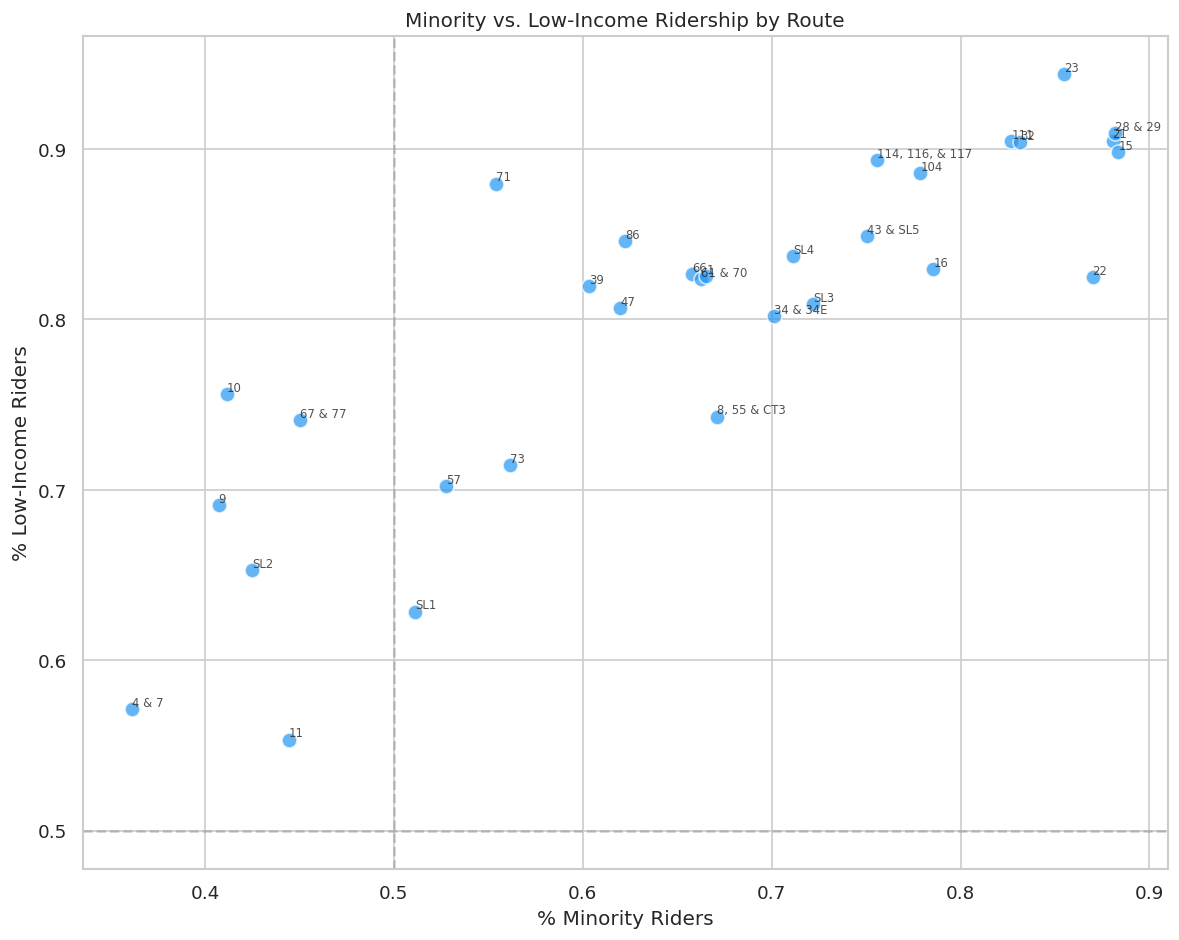

In [ ]:
if not minority_yes.empty and not lowinc_yes.empty:
    scatter_df = minority_yes[["reporting_group", "weighted_percent"]].rename(
        columns={"weighted_percent": "pct_minority"}
    )
    scatter_df = scatter_df.merge(
        lowinc_yes[["reporting_group", "weighted_percent"]].rename(
            columns={"weighted_percent": "pct_lowincome"}
        ),
        on="reporting_group",
        how="inner",
    )

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(
        scatter_df["pct_minority"],
        scatter_df["pct_lowincome"],
        c="#2196F3",
        s=80,
        alpha=0.7,
        edgecolors="white",
    )

    # Label points
    for _, row in scatter_df.iterrows():
        ax.annotate(
            row["reporting_group"],
            (row["pct_minority"], row["pct_lowincome"]),
            fontsize=7,
            alpha=0.8,
            ha="left",
            va="bottom",
        )

    ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.4)
    ax.axvline(x=0.5, color="gray", linestyle="--", alpha=0.4)
    ax.set_xlabel("% Minority Riders")
    ax.set_ylabel("% Low-Income Riders")
    ax.set_title("Minority vs. Low-Income Ridership by Route")

    # # Quadrant labels
    # ax.text(0.75, 0.75, "HIGH MINORITY\nHIGH LOW-INCOME", ha="center",
    #         fontsize=9, color="#D32F2F", fontweight="bold", alpha=0.6)
    # ax.text(0.25, 0.25, "LOW MINORITY\nLOW LOW-INCOME", ha="center",
    #         fontsize=9, color="#4CAF50", fontweight="bold", alpha=0.6)

    plt.tight_layout()
    plt.savefig("viz5_minority_vs_lowincome.png", bbox_inches="tight")
    plt.show()

In [ ]:
wide_pass_bus.to_csv("/content/drive/MyDrive/CS506 Project/wide_pass_bus_clean.csv", index=False)